Dataset:


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,Review
0,The product is excellent and works perfectly
1,I am very happy with this product
2,Amazing quality and fast delivery
3,The product is worth the money
4,Excellent service and friendly staff
5,I really loved the product
6,Very good quality and great experience
7,The product exceeded my expectations
8,Fast delivery and excellent packaging
9,I would definitely recommend this product



Cleaned Reviews:


,Review,Cleaned_Review
0,The product is excellent and works perfectly,product excellent works perfectly
1,I am very happy with this product,happy product
2,Amazing quality and fast delivery,amazing quality fast delivery
3,The product is worth the money,product worth money
4,Excellent service and friendly staff,excellent service friendly staff
5,I really loved the product,really loved product
6,Very good quality and great experience,good quality great experience
7,The product exceeded my expectations,product exceeded expectations
8,Fast delivery and excellent packaging,fast delivery excellent packaging
9,I would definitely recommend this product,would definitely recommend product



========== SENTIMENT RESULTS ==========


,Review,Sentiment
0,The product is excellent and works perfectly,Positive
1,I am very happy with this product,Positive
2,Amazing quality and fast delivery,Positive
3,The product is worth the money,Positive
4,Excellent service and friendly staff,Positive
5,I really loved the product,Positive
6,Very good quality and great experience,Positive
7,The product exceeded my expectations,Neutral
8,Fast delivery and excellent packaging,Positive
9,I would definitely recommend this product,Positive



========== SENTIMENT SCORES ==========


,Review,Sentiment,Sentiment_Score
0,The product is excellent and works perfectly,Positive,0.8360
1,I am very happy with this product,Positive,0.6115
2,Amazing quality and fast delivery,Positive,0.5859
3,The product is worth the money,Positive,0.2263
4,Excellent service and friendly staff,Positive,0.7845
5,I really loved the product,Positive,0.6361
6,Very good quality and great experience,Positive,0.8070
7,The product exceeded my expectations,Neutral,0.0000
8,Fast delivery and excellent packaging,Positive,0.5719
9,I would definitely recommend this product,Positive,0.6369



========== SENTIMENT COUNT ==========
Sentiment
Positive    13
Negative    11
Neutral      6
Name: count, dtype: int64


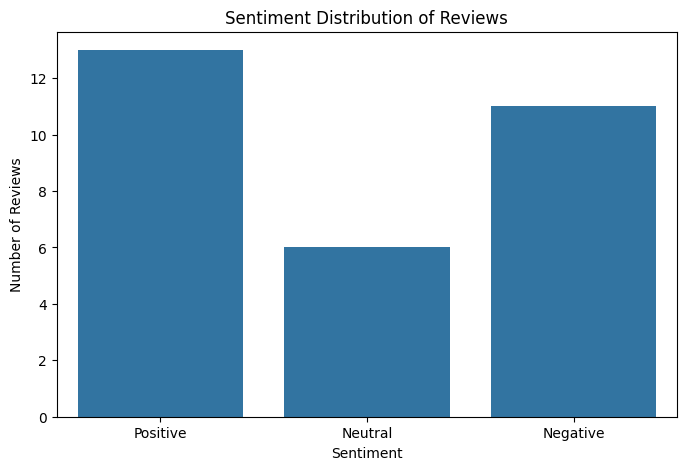


========== SENTIMENT PERCENTAGE ==========
Positive: 43.33%
Negative: 36.67%
Neutral: 20.00%


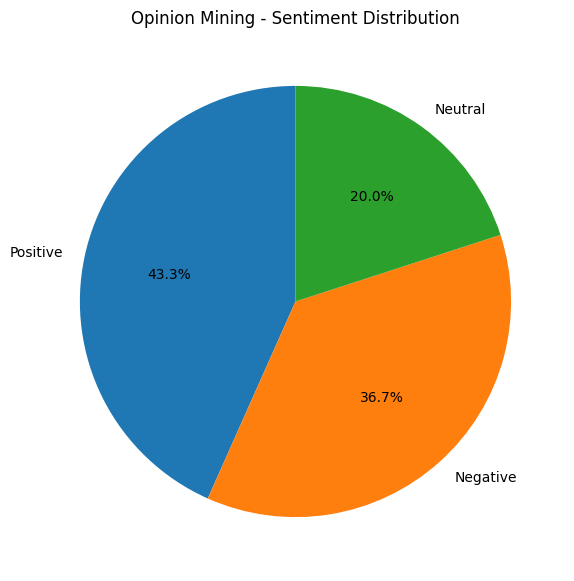


TF-IDF Matrix Shape:
(30, 50)

========== MODEL ACCURACY ==========
Accuracy: 66.67%

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67         2
     Neutral       0.00      0.00      0.00         1
    Positive       0.60      1.00      0.75         3

    accuracy                           0.67         6
   macro avg       0.53      0.50      0.47         6
weighted avg       0.63      0.67      0.60         6



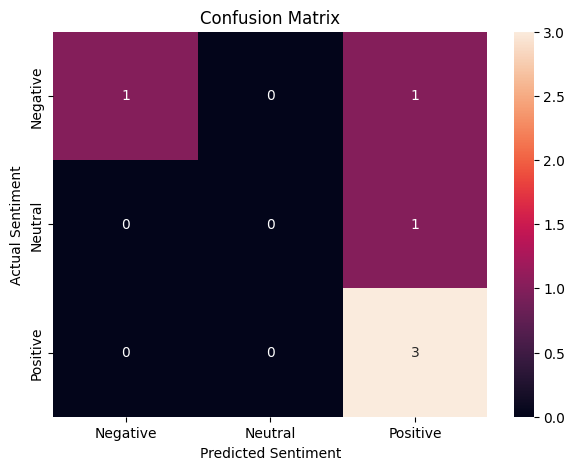


========== NEW REVIEW PREDICTIONS ==========

Review: This product is amazing and I really love it
Predicted Opinion: Positive

Review: The product quality is terrible
Predicted Opinion: Negative

Review: The product is okay and works normally
Predicted Opinion: Positive

========== FINAL DATASET ==========


,Review,Cleaned_Review,Sentiment,Sentiment_Score
0,The product is excellent and works perfectly,product excellent works perfectly,Positive,0.8360
1,I am very happy with this product,happy product,Positive,0.6115
2,Amazing quality and fast delivery,amazing quality fast delivery,Positive,0.5859
3,The product is worth the money,product worth money,Positive,0.2263
4,Excellent service and friendly staff,excellent service friendly staff,Positive,0.7845
5,I really loved the product,really loved product,Positive,0.6361
6,Very good quality and great experience,good quality great experience,Positive,0.8070
7,The product exceeded my expectations,product exceeded expectations,Neutral,0.0000
8,Fast delivery and excellent packaging,fast delivery excellent packaging,Positive,0.5719
9,I would definitely recommend this product,would definitely recommend product,Positive,0.6369


In [1]:
# ============================================================
# Opinion Mining on Product/Service Reviews Dataset
# ============================================================

# Step 1: Install Required Libraries
!pip install pandas matplotlib seaborn scikit-learn nltk


# Step 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Step 3: Download NLTK Resources
nltk.download('stopwords')
nltk.download('vader_lexicon')

stop_words = set(stopwords.words('english'))


# Step 4: Create Product/Service Reviews Dataset
reviews = [
    "The product is excellent and works perfectly",
    "I am very happy with this product",
    "Amazing quality and fast delivery",
    "The product is worth the money",
    "Excellent service and friendly staff",
    "I really loved the product",
    "Very good quality and great experience",
    "The product exceeded my expectations",
    "Fast delivery and excellent packaging",
    "I would definitely recommend this product",

    "The product is terrible and completely useless",
    "Very poor quality and bad experience",
    "I am disappointed with this product",
    "The product stopped working after one day",
    "Worst service I have ever received",
    "The delivery was very late",
    "I hate this product",
    "The quality is extremely poor",
    "Not worth the money",
    "I would not recommend this product",

    "The product is okay",
    "The quality is average",
    "The product is neither good nor bad",
    "Delivery was normal",
    "The service was satisfactory",
    "It is an average product",
    "The product works as expected",
    "Nothing special about this product",
    "The experience was okay",
    "The product is acceptable"
]

df = pd.DataFrame({
    "Review": reviews
})

print("Dataset:")
display(df)


# Step 5: Text Preprocessing Function
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# Apply preprocessing
df["Cleaned_Review"] = df["Review"].apply(preprocess_text)

print("\nCleaned Reviews:")
display(df.head(10))


# Step 6: Sentiment Analysis using VADER
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


df["Sentiment"] = df["Review"].apply(get_sentiment)

print("\n========== SENTIMENT RESULTS ==========")
display(df[["Review", "Sentiment"]])


# Step 7: Display Sentiment Scores
def get_score(text):
    return sia.polarity_scores(text)["compound"]

df["Sentiment_Score"] = df["Review"].apply(get_score)

print("\n========== SENTIMENT SCORES ==========")
display(df[["Review", "Sentiment", "Sentiment_Score"]])


# Step 8: Count Positive, Negative and Neutral Reviews
sentiment_counts = df["Sentiment"].value_counts()

print("\n========== SENTIMENT COUNT ==========")
print(sentiment_counts)


# Step 9: Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()


# Step 10: Sentiment Percentage
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    * 100
)

print("\n========== SENTIMENT PERCENTAGE ==========")

for sentiment, percentage in sentiment_percentage.items():
    print(f"{sentiment}: {percentage:.2f}%")


# Step 11: Pie Chart
plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Opinion Mining - Sentiment Distribution")

plt.show()


# Step 12: Convert Text into TF-IDF Features
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])

y = df["Sentiment"]

print("\nTF-IDF Matrix Shape:")
print(X.shape)


# Step 13: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Step 14: Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# Step 15: Make Predictions
y_pred = model.predict(X_test)


# Step 16: Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n========== MODEL ACCURACY ==========")
print(f"Accuracy: {accuracy * 100:.2f}%")


# Step 17: Classification Report
print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# Step 18: Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")

plt.show()


# Step 19: Test New Reviews
new_reviews = [
    "This product is amazing and I really love it",
    "The product quality is terrible",
    "The product is okay and works normally"
]

new_cleaned = [
    preprocess_text(review)
    for review in new_reviews
]

new_features = vectorizer.transform(new_cleaned)

predictions = model.predict(new_features)

print("\n========== NEW REVIEW PREDICTIONS ==========")

for review, prediction in zip(new_reviews, predictions):
    print(f"\nReview: {review}")
    print(f"Predicted Opinion: {prediction}")


# Step 20: Final Dataset
print("\n========== FINAL DATASET ==========")

display(
    df[
        [
            "Review",
            "Cleaned_Review",
            "Sentiment",
            "Sentiment_Score"
        ]
    ]
)